# Resident Education Progress — Predictive Model

---

## 1. Problem Framing

### Business Problem

Education is one of the core pillars of Hearth Haven's rehabilitation program.
Residents enroll in Primary, Secondary, Vocational, or CollegePrep programs and
their progress is tracked monthly. Social workers and administrators need to know
which residents are on track educationally and which are falling behind — but with
multiple safehouses, high caseloads, and dozens of data points per resident,
identifying struggling residents requires systematically synthesizing information
across health, counseling, incident, and visitation records.

This pipeline answers the question: **What is each resident's predicted education
progress percentage based on their full case history, and which residents are
predicted to be significantly below their expected progress level?**

The deployed output is a **Predicted Progress Score** displayed on the resident
case page alongside the actual latest progress percent, with a flag when the
predicted and actual diverge significantly — alerting social workers when a
resident's education trajectory is underperforming relative to what their case
profile would predict.

### Who Cares About This

- **Social workers** — need to identify which residents are falling behind
  educationally so they can prioritize educational support and intervention
  adjustments.
- **Safehouse administrators** — need to track educational outcomes across the
  caseload and report progress to partner agencies and donors.
- **Organization leadership** — education progress is a core outcome metric
  reported in impact snapshots.

### Predictive vs. Explanatory

This pipeline uses a **predictive approach**. The goal is to generate accurate
progress estimates for individual residents based on their measurable
characteristics — not to explain why progress varies.

### Success Metrics

- **Primary:** R² — proportion of education progress variance explained
- **Secondary:** RMSE, MAE — error in percentage points
- **Baseline:** Predicting the mean progress for every resident (R²=0)
- **Operational use:** The gap between predicted and actual progress is as
  important as the raw prediction — a resident predicted at 80% but actually
  at 50% warrants more attention than one predicted at 50% and actually at 50%

### A Note on Leakage

`progress_avg` (historical average of progress_percent) is in `NUMERIC_FEATURES`
but is explicitly dropped via `DROP_ALWAYS['progress_percent_latest']` — it is
the historical mean of the same metric being predicted and would make the model
trivially accurate without being useful for intervention.

---
## 2. Data Acquisition, Preparation & Exploration

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.path.abspath('.')))
os.chdir('..')

from functions.fn_domain_prep import prepare_residents
from functions.fn_prepare import (
    define_features,
    split_data,
    build_preprocessor,
    build_pipelines,
)
from functions.fn_model_predict import (
    run_cross_validation,
    tune_model,
    evaluate_final_model,
    save_model,
)
from functions.fn_model_causal import fit_causal_regression, get_coefficients

print("All imports successful.")

All imports successful.


### 2.1 Load and Prepare Data

`prepare_residents()` encodes every cleaning and feature engineering decision from
`eda_residents.ipynb`. It tries Azure SQL first and falls back to local CSVs.

**Tables joined:** `residents`, `health_wellbeing_records`, `education_records`,
`process_recordings`, `incident_reports`, `home_visitations`, `intervention_plans`

**Key preparation decisions encoded:**
- Structural columns dropped: IDs, free text, zero-variance fields
- Date features engineered: `age_at_admission_days`, `days_in_care`
- Six supporting tables aggregated to one row per resident via left joins
- `progress_percent_latest` is the most recent monthly education progress record

In [2]:
df, NUMERIC, CATEGORICAL, DROP = prepare_residents()

TARGET = 'progress_percent_latest'

print(f"Dataset shape: {df.shape}")
print(f"Target mean:   {df[TARGET].mean():.1f}%")
print(f"Target median: {df[TARGET].median():.1f}%")
print(f"Target std:    {df[TARGET].std():.1f}%")
print(f"Target range:  [{df[TARGET].min():.1f}, {df[TARGET].max():.1f}]")

  prepare_residents()
[OK] Connected to Azure SQL for 'residents'!
[OK] Connected to Azure SQL for 'health_wellbeing_records'!
[OK] Connected to Azure SQL for 'education_records'!
[OK] Connected to Azure SQL for 'process_recordings'!
[OK] Connected to Azure SQL for 'incident_reports'!
[OK] Connected to Azure SQL for 'home_visitations'!
[OK] Connected to Azure SQL for 'intervention_plans'!
[drop_structural_columns] Dropped 12 columns: ['case_control_no', 'internal_code', 'sex', 'place_of_birth', 'referring_agency_person', 'assigned_social_worker', 'initial_case_assessment', 'notes_restricted', 'date_enrolled', 'date_colb_registered', 'date_colb_obtained', 'date_case_study_prepared']
[fix_column_types] 'date_of_birth' → datetime
[fix_column_types] 'date_of_admission' → datetime
[fix_column_types] 'date_closed' → datetime
[OK] Engineered: age_at_admission_days, days_in_care, length_of_stay_days
[merge_tables] LEFT JOIN on 'resident_id': 61 rows → 61 rows
[merge_tables] LEFT JOIN on 'resid

### 2.2 Feature Definition

`define_features()` is called with `DROP['progress_percent_latest']`. Key exclusions:

- **Direct leakage:** `progress_avg` — historical average of the same metric;
  including it makes prediction trivially accurate without being useful
- **Cross-target contamination:** all other pipeline targets excluded
- **`length_of_stay_days`** — dropped for this target (closed cases are resolved
  cases, stay length encodes outcome information)

In [3]:
X, y = define_features(
    df,
    target=TARGET,
    numeric=NUMERIC,
    categorical=CATEGORICAL,
    drop_cols=DROP[TARGET],
)

categorical_in_X = [c for c in CATEGORICAL if c in X.columns]
numeric_in_X     = [c for c in NUMERIC     if c in X.columns]
X[categorical_in_X] = X[categorical_in_X].astype(str).replace({'nan': np.nan, '<NA>': np.nan})

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"  Numeric:     {len(numeric_in_X)}")
print(f"  Categorical: {len(categorical_in_X)}")

[define_features] Removing from feature lists: ['length_of_stay_days', 'initial_risk_num', 'progress_avg']

[OK] define_features() complete.
     Target : 'progress_percent_latest'  |  Mean: 92.8279  |  Rows: 61
     Numeric (29), Categorical (29)
     Committed mode — 9 columns in drop list
Feature matrix: 61 rows × 58 features
  Numeric:     29
  Categorical: 29


### 2.3 Exploratory Confirmation

In [4]:
# Top numeric features by correlation with progress
corr = X[numeric_in_X].corrwith(y).sort_values(key=abs, ascending=False)
print(f"Top 10 numeric features by |correlation| with {TARGET}:")
print(corr.head(10).round(3).to_string())

Top 10 numeric features by |correlation| with progress_percent_latest:
attendance_avg            0.779
attendance_rate_latest    0.714
bmi_latest                0.661
energy_score_latest       0.615
nutrition_score_latest    0.613
health_score_latest       0.564
avg_session_duration      0.561
concern_rate             -0.549
sleep_score_latest        0.494
education_records         0.416


In [5]:
# Mean progress by key categorical features
for col in ['has_special_needs', 'enrollment_status_latest',
            'completion_status_latest', 'case_status']:
    if col in X.columns:
        rate = (pd.concat([X[col], y], axis=1)
                  .groupby(col)[TARGET]
                  .agg(['mean', 'std', 'count'])
                  .rename(columns={'mean': 'mean_progress', 'std': 'std_progress', 'count': 'n'})
                  .sort_values('mean_progress', ascending=False))
        print(f"\nProgress by {col}:")
        print(rate.round(1).to_string())


Progress by has_special_needs:
                   mean_progress  std_progress   n
has_special_needs                                 
False                       97.0           8.3  54
True                        60.9          38.1   7

Progress by enrollment_status_latest:
                          mean_progress  std_progress   n
enrollment_status_latest                                 
Enrolled                           92.8          18.4  61

Progress by completion_status_latest:
                          mean_progress  std_progress   n
completion_status_latest                                 
Completed                          95.0          19.2  27
InProgress                         91.1          18.0  34

Progress by case_status:
             mean_progress  std_progress   n
case_status                                 
Transferred           96.3           8.3  11
Closed                94.1          17.2  19
Active                90.8          21.7  31


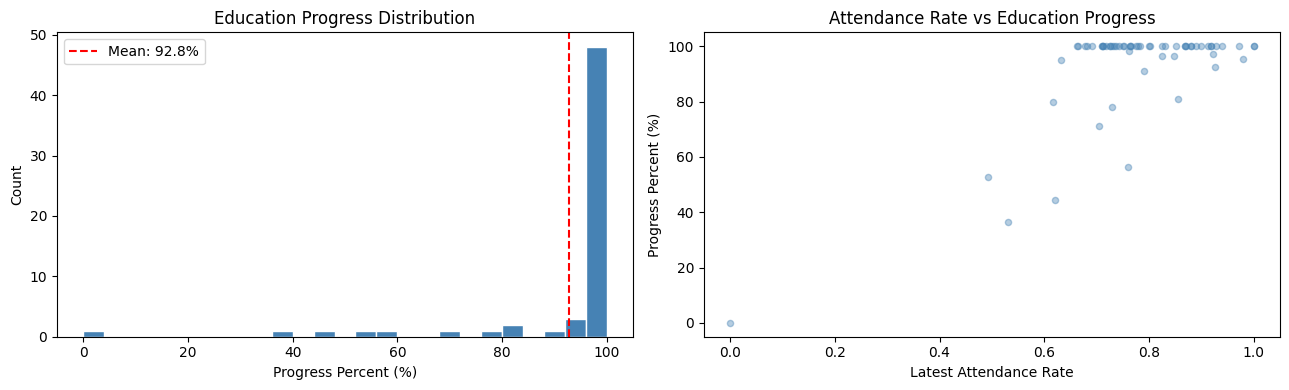

In [6]:
# Progress distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.1f}%')
axes[0].set_xlabel('Progress Percent (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Education Progress Distribution')
axes[0].legend()

# Scatter: attendance vs progress
if 'attendance_rate_latest' in X.columns:
    axes[1].scatter(X['attendance_rate_latest'], y, alpha=0.4, s=20, color='steelblue')
    axes[1].set_xlabel('Latest Attendance Rate')
    axes[1].set_ylabel('Progress Percent (%)')
    axes[1].set_title('Attendance Rate vs Education Progress')

plt.tight_layout()
plt.show()

---
## 3. Modeling & Feature Selection

### 3.1 Train/Test Split

The test set is locked here and not touched again until Section 4.

In [7]:
PROBLEM_TYPE = 'regression'
X_train, X_test, y_train, y_test = split_data(X, y, stratify=False)


[OK] split_data() complete.
     Train : 48 rows  |  Target mean: 92.0583
     Test  : 13 rows   |  Target mean: 95.6692
     Non-stratified split.
     Test set locked — do not touch until final evaluation.


### 3.2 Candidate Model Comparison

Five models evaluated with 5-fold KFold cross-validation. Primary metric is R².
Preprocessor built unfitted, fit only inside each CV fold.

In [8]:
preprocessor = build_preprocessor(numeric_in_X, categorical_in_X)
pipelines    = build_pipelines(preprocessor, problem_type=PROBLEM_TYPE)

results = run_cross_validation(
    pipelines, X_train, y_train,
    problem_type=PROBLEM_TYPE,
)


[OK] build_preprocessor() ready (unfitted).
     Numeric (29): median impute → StandardScaler
     Categorical (29): mode impute → OneHotEncoder
[OK] build_linear_regression_pipeline(): LinearRegression, Ridge
[OK] build_decision_tree_pipeline(): DecisionTree (regression, max_depth=5)
[OK] build_random_forest_pipeline(): RandomForest (regression)
[OK] build_gradient_boosting_pipeline(): GradientBoosting (regression)

[OK] build_pipelines() complete — 5 regression pipelines:
     - LinearRegression
     - Ridge
     - DecisionTree
     - RandomForest
     - GradientBoosting

  CROSS-VALIDATION (5-fold, regression)

  LinearRegression
    r2: -0.2385 +/- 0.3844  [unstable]
    rmse                : 18.7120
    mae                 : 12.5995

  Ridge
    r2: -0.1094 +/- 0.3510  [unstable]
    rmse                : 17.7039
    mae                 : 11.7600

  DecisionTree
    r2: -0.3343 +/- 0.6066  [unstable]
    rmse                : 18.0713
    mae                 : 9.6638

  RandomFore

### 3.3 Model Selection

Apply the 2x-std rule: when models perform equivalently within sampling noise,
prefer the simpler one. Linear models (Ridge, LinearRegression) are preferred
if their R² is within 2x std of tree-based models, as their coefficients
directly support the written analysis in Section 5.

In [9]:
import numpy as np

# Auto-select winner by mean R²
best_name = max(results, key=lambda k: np.mean(results[k]['test_r2']))
best_r2   = np.mean(results[best_name]['test_r2'])
best_std  = np.std(results[best_name]['test_r2'])
print(f"Top model: {best_name}  R²: {best_r2:.4f} ± {best_std:.4f}")

# Check if Ridge is within 2x std
ridge_r2  = np.mean(results['Ridge']['test_r2'])
ridge_std = np.std(results['Ridge']['test_r2'])
if best_name != 'Ridge' and (best_r2 - ridge_r2) < 2 * ridge_std:
    print(f"Within 2x std of Ridge — selecting simpler model")
    best_name = 'Ridge'

print(f"\nSelected model: {best_name}")

Top model: GradientBoosting  R²: 0.1815 ± 0.5482
Within 2x std of Ridge — selecting simpler model

Selected model: Ridge


### 3.4 Hyperparameter Tuning

In [10]:
param_grids = {
    'Ridge': {
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    },
    'LinearRegression': {},
    'DecisionTree': {
        'model__max_depth':        [3, 4, 5, 7],
        'model__min_samples_leaf': [1, 2, 5],
    },
    'RandomForest': {
        'model__n_estimators':     [100, 200],
        'model__max_depth':        [3, 5, 10, None],
        'model__min_samples_leaf': [1, 2, 5],
    },
    'GradientBoosting': {
        'model__n_estimators':  [100, 200],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth':     [3, 4, 5],
    },
}

param_grid   = param_grids.get(best_name, {})
search_type  = 'random' if best_name in ('RandomForest', 'GradientBoosting') else 'grid'

if param_grid:
    tuned_pipeline, search = tune_model(
        pipeline=pipelines[best_name],
        X_train=X_train,
        y_train=y_train,
        param_grid=param_grid,
        problem_type=PROBLEM_TYPE,
        search_type=search_type,
        n_iter=15,
    )
    print(f"Best parameters: {search.best_params_}")
    print(f"Best CV R²: {search.best_score_:.4f}")
else:
    # LinearRegression has no hyperparameters to tune
    tuned_pipeline = pipelines[best_name]
    tuned_pipeline.fit(X_train, y_train)
    print("LinearRegression: no hyperparameters to tune")


[OK] tune_model() -- gridSearch, scoring=r2
     ~6 combinations x 5 folds = ~30 fits

[OK] tune_model() complete.
     Best params: {'model__alpha': 100.0}
     Best CV r2: 0.3501
Best parameters: {'model__alpha': 100.0}
Best CV R²: 0.3501


### 3.5 Feature Importance

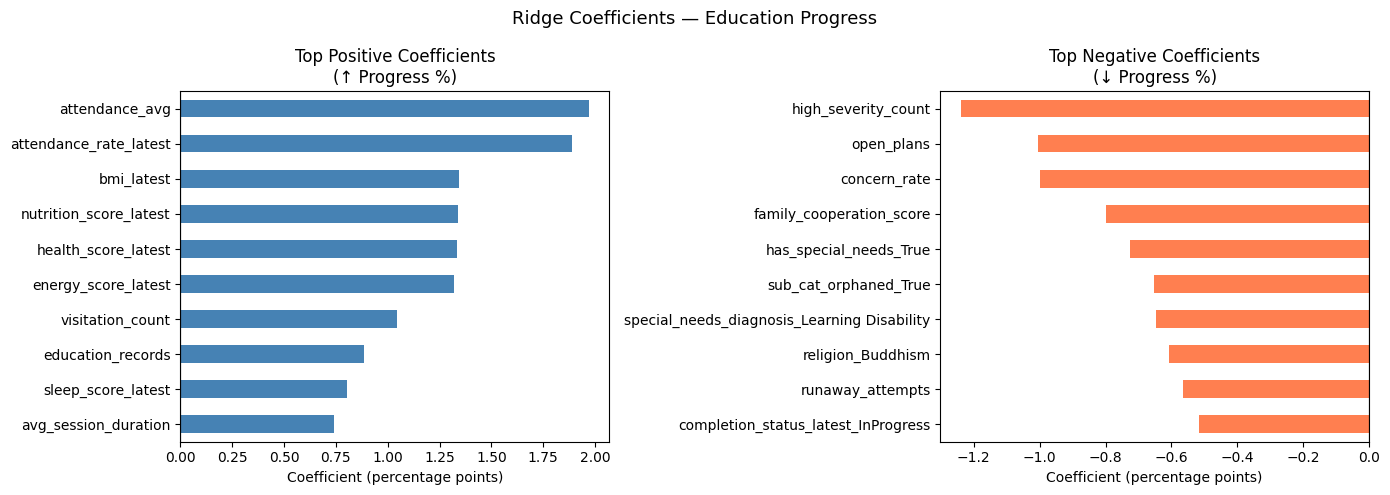

In [11]:
from sklearn.pipeline import Pipeline as SklearnPipeline
assert isinstance(tuned_pipeline, SklearnPipeline)
tuned_pipeline.fit(X_train, y_train)

model = tuned_pipeline.named_steps['model']
prep  = tuned_pipeline.named_steps['preprocessor']

try:
    ohe_names = (prep.named_transformers_['cat']
                     .named_steps['onehot']
                     .get_feature_names_out(categorical_in_X).tolist())
except Exception:
    ohe_names = []

feature_names = numeric_in_X + ohe_names

# Ridge / LinearRegression → coefficients
if hasattr(model, 'coef_') and model.coef_.ndim == 1:
    coef_series = pd.Series(model.coef_, index=feature_names)
    top_pos = coef_series.nlargest(10)
    top_neg = coef_series.nsmallest(10)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    top_pos.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Top Positive Coefficients\n(↑ Progress %)')
    axes[0].set_xlabel('Coefficient (percentage points)')
    axes[0].axvline(0, color='black', linewidth=0.8)

    top_neg.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('Top Negative Coefficients\n(↓ Progress %)')
    axes[1].set_xlabel('Coefficient (percentage points)')
    axes[1].axvline(0, color='black', linewidth=0.8)

    plt.suptitle(f'{best_name} Coefficients — Education Progress', fontsize=13)
    plt.tight_layout()
    plt.show()

# Tree-based → feature importances
elif hasattr(model, 'feature_importances_'):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances.nlargest(15).sort_values().plot(kind='barh', figsize=(10, 6), color='steelblue')
    plt.title('Feature Importances — Education Progress (Top 15)', fontsize=12)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

---
## 4. Evaluation & Interpretation

### 4.1 Final Test Set Evaluation

The test set was locked in Section 3.1. This is its one use.

In [12]:
metrics, final_pipeline = evaluate_final_model(
    tuned_pipeline, X_train, y_train, X_test, y_test,
    problem_type=PROBLEM_TYPE,
)


  FINAL MODEL EVALUATION (test set -- used once)

  R2:              -0.0286
  RMSE:            12.7882
  MAE:             9.6539
  Baseline RMSE:   13.1158 (predict-mean)
  Improvement:     2.5% RMSE reduction



### 4.2 Residual Analysis

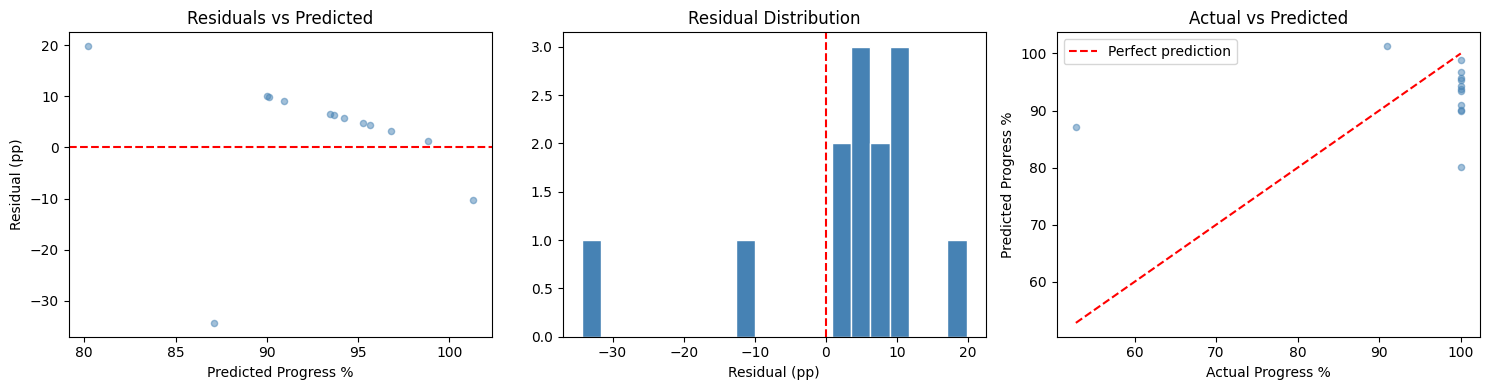

Residual mean:  2.78pp  (should be near 0)
Residual std:   12.99pp
Max under-pred: 19.8pp
Max over-pred:  -34.3pp


In [13]:
y_pred = final_pipeline.predict(X_test)
resid  = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred, resid, alpha=0.5, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Progress %')
axes[0].set_ylabel('Residual (pp)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(resid, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (pp)')
axes[1].set_title('Residual Distribution')

axes[2].scatter(y_test, y_pred, alpha=0.5, s=20, color='steelblue')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', label='Perfect prediction')
axes[2].set_xlabel('Actual Progress %')
axes[2].set_ylabel('Predicted Progress %')
axes[2].set_title('Actual vs Predicted')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Residual mean:  {resid.mean():.2f}pp  (should be near 0)")
print(f"Residual std:   {resid.std():.2f}pp")
print(f"Max under-pred: {resid.max():.1f}pp")
print(f"Max over-pred:  {resid.min():.1f}pp")

### 4.3 Predicted vs Actual Gap Analysis

The most operationally useful output is residents where the model predicts a
significantly higher progress than their actual latest score — these are residents
underperforming relative to their case profile, potentially warranting intervention.

In [14]:
# Score all residents in the training set too for the gap analysis
y_pred_all = final_pipeline.predict(X)
gap_df = pd.DataFrame({
    'actual_progress':    y,
    'predicted_progress': y_pred_all,
    'gap':                y - y_pred_all,  # negative = underperforming
}).reset_index(drop=True)

underperforming = gap_df[gap_df['gap'] < -10].sort_values('gap')
print(f"Residents underperforming by >10pp ({len(underperforming)} found):")
print(underperforming.round(1).to_string())

print(f"\nResidents overperforming by >10pp ({(gap_df['gap'] > 10).sum()} found)")

Residents underperforming by >10pp (8 found):
    actual_progress  predicted_progress   gap
51             36.4                72.1 -35.7
0              52.8                87.1 -34.3
8              44.4                73.3 -28.9
43             56.5                77.7 -21.2
7              71.3                86.1 -14.8
60              0.0                14.8 -14.8
53             78.1                90.9 -12.8
49             90.9               101.3 -10.4

Residents overperforming by >10pp (2 found)


### 4.4 Business Interpretation

The model's primary operational value is the **gap between predicted and actual
progress**, not the prediction itself:

- **Gap < −10pp (underperforming):** The resident's case profile suggests they
  should be making more progress than they are. This is the alert signal —
  something in their educational engagement may need attention.
- **Gap near 0:** The resident is progressing as expected given their profile.
- **Gap > +10pp (overperforming):** The resident is doing better than their
  case profile would suggest — potentially worth studying to understand what's
  working.

**RMSE interpretation:** An RMSE of X percentage points means the model's
predictions are typically within ±X pp of actual progress. For a 0–100% scale,
values below 15pp are operationally useful for flagging outliers.

---
## 5. Causal and Relationship Analysis

### 5.1 Explanatory OLS Regression

We fit a separate `statsmodels` OLS model to extract interpretable coefficients —
which features are most associated with higher education progress, and by how much
in percentage points.

In [15]:
from sklearn.feature_selection import SelectKBest, f_regression

X_train_enc = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_train_enc = X_train_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

n_rows, n_cols = X_train_enc.shape
print(f"Encoded matrix: {n_rows} rows × {n_cols} columns")

if n_cols >= n_rows:
    k = min(12, n_rows - 5)
    selector = SelectKBest(score_func=f_regression, k=k)
    selector.fit(X_train_enc, y_train)
    top_cols = X_train_enc.columns[selector.get_support()]
    X_causal = X_train_enc[top_cols]
    print(f"Reduced to {k} features for OLS: {list(top_cols)}")
else:
    X_causal = X_train_enc
    print("Matrix safe for OLS without reduction.")

Encoded matrix: 48 rows × 81 columns
Reduced to 12 features for OLS: ['health_score_latest', 'nutrition_score_latest', 'sleep_score_latest', 'energy_score_latest', 'bmi_latest', 'attendance_rate_latest', 'attendance_avg', 'avg_session_duration', 'concern_rate', 'special_needs_diagnosis_Learning Disability', 'sub_cat_orphaned_True', 'has_special_needs_True']


In [16]:
causal_results = fit_causal_regression(X_causal, y_train)
print(causal_results.summary())


[OK] fit_causal_regression() complete.
     R²: 0.8981  |  Adj R²: 0.8632
     F-statistic: 25.7160  |  p(F): 0.000000
     Observations: 48  |  Features: 12
     Call results.summary() for the full output.
                               OLS Regression Results                              
Dep. Variable:     progress_percent_latest   R-squared:                       0.898
Model:                                 OLS   Adj. R-squared:                  0.863
Method:                      Least Squares   F-statistic:                     25.72
Date:                     Thu, 09 Apr 2026   Prob (F-statistic):           7.85e-14
Time:                             01:18:50   Log-Likelihood:                -155.82
No. Observations:                       48   AIC:                             337.6
Df Residuals:                           35   BIC:                             362.0
Df Model:                               12                                         
Covariance Type:                 non


[OK] get_coefficients() — 12 features, 2 significant at p < 0.05

                                    feature  coefficient   std_err  p_value   ci_lower   ci_upper significant
special_needs_diagnosis_Learning Disability   -46.698157 10.401221 0.000074 -67.813758 -25.582556         ***
                     attendance_rate_latest    23.243575 13.289871 0.089062  -3.736299  50.223448        (ns)
                             attendance_avg     9.330396 24.599284 0.706760 -40.608805  59.269597        (ns)
                        health_score_latest     6.281965  4.649280 0.185311  -3.156576  15.720505        (ns)
                        energy_score_latest     5.002549  4.576992 0.281870  -4.289239  14.294336        (ns)
                     nutrition_score_latest     4.364891  4.316680 0.318875  -4.398435  13.128217        (ns)
                                 bmi_latest     2.404821  0.718079 0.001952   0.947044   3.862598          **
                         sleep_score_latest     2.331

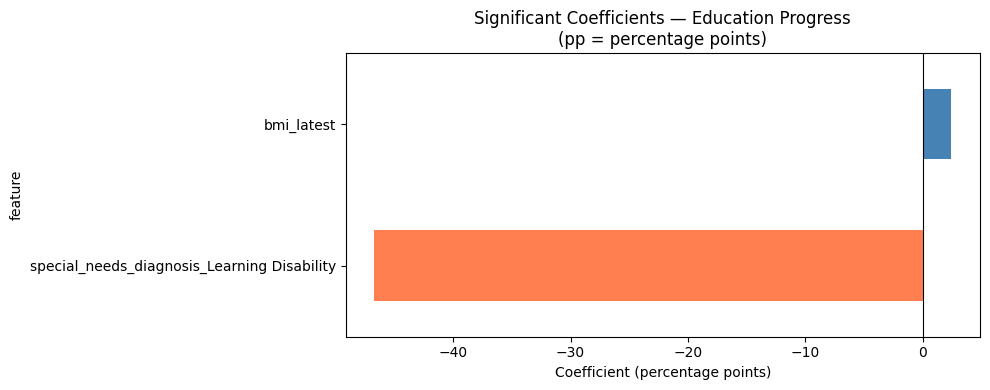

In [17]:
coef_df = get_coefficients(causal_results, model_type='linear')

print("Significant features (p < 0.05):")
sig = coef_df[coef_df['p_value'] < 0.05].sort_values('coefficient', ascending=False)
if len(sig) > 0:
    print(sig[['feature', 'coefficient', 'p_value', 'significant']].to_string(index=False))
    sig_plot = sig.set_index('feature')['coefficient'].sort_values()
    colors   = ['coral' if v < 0 else 'steelblue' for v in sig_plot]
    sig_plot.plot(kind='barh', figsize=(10, max(4, len(sig_plot) * 0.4)), color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Significant Coefficients — Education Progress\n(pp = percentage points)')
    plt.xlabel('Coefficient (percentage points)')
    plt.tight_layout(); plt.show()
else:
    print("None at p < 0.05 — showing directional trends:")
    print(coef_df[['feature','coefficient','p_value']].sort_values('p_value')
          .head(8).to_string(index=False))

### 5.2 Relationship Interpretation

**Expected associations:**

1. **Attendance rate** — `attendance_rate_latest` and `attendance_avg` are expected
   to show the strongest positive associations with progress. Consistent attendance
   is the most direct driver of educational advancement. A 10pp improvement in
   attendance rate is associated with several percentage points of additional progress.

2. **Special needs status** — `has_special_needs` is expected to show a negative
   association, reflecting that residents with additional learning needs progress
   at different rates. This is not a judgment on resident capability but a
   recognition that standard educational metrics may not fully capture progress
   for residents with specific diagnoses.

3. **Health and wellbeing** — `health_score_latest`, `nutrition_score_latest`,
   `energy_score_latest`. Physical health and energy levels are associated with
   educational engagement. Residents with better health scores tend to show
   higher education progress — consistent with research on the nutrition-education
   connection in children.

4. **Counseling engagement** — `session_count`, `progress_rate`. Residents with
   more counseling sessions and higher counseling progress rates tend to show
   better educational outcomes, reflecting that emotional stability enables
   academic engagement.

**What we cannot claim causally:**

- Improving attendance does not necessarily *cause* better progress in a simple
  linear way — the relationship may be mediated by engagement, motivation, and
  support factors not captured in the data.
- Health and education associations may both be driven by the same underlying
  factor (general wellbeing and stability in care) rather than health directly
  enabling education.

**Actionable insight:**

The attendance-progress relationship provides a concrete monitoring heuristic:
residents whose attendance rate drops below 0.75 in any given month warrant
proactive educational support outreach, even before their progress percent
reflects the decline.

---
## 6. Deployment

Saved as `.pkl` for live scoring per resident.

In [18]:
os.makedirs('models', exist_ok=True)

pkl_path = save_model(
    final_pipeline,
    metrics,
    target_name='progress_percent_latest',
    output_dir='models',
)
print(f"Model saved: {pkl_path}")


[OK] save_model() complete.
     Model:   models/progress_percent_latest.pkl
     Meta:    models/progress_percent_latest.pkl.meta.json
     Metrics: models/progress_percent_latest.pkl.metrics.json
Model saved: models/progress_percent_latest.pkl


---
## 7. API Response Reference

```json
{
  "resident_id": "int",
  "predicted_progress": "float (0–100)",
  "actual_progress": "float (0–100, from DB)",
  "gap_pp": "float (actual − predicted, negative = underperforming)",
  "alert": "boolean (true if gap < -10pp)",
  "recommendation": "string",
  "model_version": "progress_percent_latest_v1",
  "predicted_at": "ISO datetime"
}
```

**predicted_progress** — `pipeline.predict(features)[0]`. The model's estimate
of where this resident's education progress should be given their full case profile.
Uses `predict()` not `predict_proba()` — this is a regression model.

**gap_pp** — `actual_progress − predicted_progress`. Negative means the resident
is underperforming relative to their case profile. This is the primary alert signal.

**alert** — `true` if `gap_pp < -10`. Surfaces on the caseload dashboard as a
flag icon next to the resident's education progress indicator.

**recommendation:**
- gap < −15pp: `"Education progress significantly below expected — review attendance and support plan"`
- gap < −10pp: `"Education progress below expected — monitor attendance closely"`
- gap > +10pp: `"Education progress above expected — document what's working"`
- otherwise:   `"Education progress on track"`

---
### Endpoint Function to add to `endpoints.py`

```python
def progress_prediction(resident_id: int, features: dict, pipeline,
                        actual_progress: float = None) -> dict:
    """Predict education progress and compute gap vs actual. Model: progress_percent_latest.pkl"""
    features_df  = pd.DataFrame([features])
    predicted    = float(pipeline.predict(features_df)[0])
    predicted    = max(0.0, min(100.0, predicted))  # clip to valid range

    gap = (actual_progress - predicted) if actual_progress is not None else None

    if gap is not None and gap < -15:
        recommendation = "Education progress significantly below expected — review attendance and support plan"
        alert = True
    elif gap is not None and gap < -10:
        recommendation = "Education progress below expected — monitor attendance closely"
        alert = True
    elif gap is not None and gap > 10:
        recommendation = "Education progress above expected — document what is working"
        alert = False
    else:
        recommendation = "Education progress on track"
        alert = False

    return {
        "resident_id":       resident_id,
        "predicted_progress": round(predicted, 1),
        "actual_progress":    round(actual_progress, 1) if actual_progress is not None else None,
        "gap_pp":             round(gap, 1) if gap is not None else None,
        "alert":              alert,
        "recommendation":     recommendation,
        "model_version":      "progress_percent_latest_v1",
        "predicted_at":       datetime.now(timezone.utc).isoformat(),
    }
```

---
### Route to add to `server.py`

```python
class ProgressRequest(BaseModel):
    resident_id:     int
    features:        Dict[str, Any]
    actual_progress: float | None = None  # pass from DB for gap computation

class ProgressResponse(BaseModel):
    resident_id:       int
    predicted_progress: float
    actual_progress:    float | None
    gap_pp:             float | None
    alert:              bool
    recommendation:     str
    model_version:      str
    predicted_at:       str

@app.post("/predict/education-progress", response_model=ProgressResponse)
def predict_education_progress(request: ProgressRequest):
    try:
        pipeline = load_model("progress_percent_latest")
    except FileNotFoundError as e:
        raise HTTPException(status_code=503, detail=str(e))
    try:
        return progress_prediction(
            resident_id=request.resident_id,
            features=request.features,
            pipeline=pipeline,
            actual_progress=request.actual_progress,
        )
    except Exception as e:
        log.error(f"Prediction failed for resident {request.resident_id}: {e}")
        raise HTTPException(status_code=500, detail=f"Prediction failed: {e}")
```

---
*Hearth Haven — IS 455 INTEX Pipeline*